In [ ]:
import requests
import csv
import os
import time
import sys

# --- Configuration --- #
WEATHER_API_URL = "https://api.open-meteo.com/v1/forecast?latitude=22.7204&longitude=75.8682&current=temperature_2m,visibility&timezone=auto"
OUTPUT_FILENAME = "weather_attributes.csv"
LOGGING_INTERVAL_SECONDS = 1800  # 30 minutes
CSV_HEADERS = [
    "Time",
    "Temperature (°C)",
    "Visibility (m)"
]

# --- Functions --- #

def _initialize_csv_file(filename: str, headers: list):
    """Creates the CSV file with headers if it doesn't already exist."""
    if not os.path.exists(filename):
        try:
            with open(filename, "w", newline="") as file:
                writer = csv.writer(file)
                writer.writerow(headers)
            print(f"Created new CSV file: {filename} with headers.")
        except IOError as e:
            print(f"Error creating CSV file {filename}: {e}", file=sys.stderr)
            sys.exit(1)

def _fetch_weather_data(url: str) -> dict or None:
    """Fetches current weather data from the Open-Meteo API."""
    try:
        response = requests.get(url)
        response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
        data = response.json()["current"]
        return data
    except requests.exceptions.RequestException as e:
        print(f"Error fetching weather data: {e}", file=sys.stderr)
        return None
    except KeyError:
        print("Error: 'current' key not found in API response. API structure might have changed.", file=sys.stderr)
        return None
    except Exception as e:
        print(f"An unexpected error occurred during data fetching: {e}", file=sys.stderr)
        return None

def _save_weather_to_csv(filename: str, weather_data: dict):
    """Appends the fetched weather data to the CSV file."""
    try:
        with open(filename, "a", newline="") as file:
            writer = csv.writer(file)
            writer.writerow([
                weather_data["time"],
                weather_data["temperature_2m"],
                weather_data["visibility"]
            ])
        print(f"Saved weather data for {weather_data['time']} to {filename}")
    except IOError as e:
        print(f"Error writing to CSV file {filename}: {e}", file=sys.stderr)
    except KeyError as e:
        print(f"Missing expected weather data key: {e}. Data not saved.", file=sys.stderr)

def main():
    """Main function to run the continuous weather logging process."""
    _initialize_csv_file(OUTPUT_FILENAME, CSV_HEADERS)
    print("Weather logger started...")

    while True:
        weather_data = _fetch_weather_data(WEATHER_API_URL)
        if weather_data:
            _save_weather_to_csv(OUTPUT_FILENAME, weather_data)

        try:
            print(f"Waiting for {LOGGING_INTERVAL_SECONDS / 60} minutes before next fetch...")
            time.sleep(LOGGING_INTERVAL_SECONDS)
        except KeyboardInterrupt:
            print("Weather logger stopped.")
            break
        except Exception as e:
            print(f"An error occurred during sleep: {e}", file=sys.stderr)
            break

# --- Script Entry Point --- #
if __name__ == "__main__":
    main()


Created new CSV file: weather_attributes.csv with headers.
Weather logger started...
Saved weather data for 2026-07-22T22:45 to weather_attributes.csv
Waiting for 30.0 minutes before next fetch...
Weather logger stopped.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
try:
    df = pd.read_csv(OUTPUT_FILENAME)
    print(f"Successfully loaded {OUTPUT_FILENAME}")
except FileNotFoundError:
    print(f"Error: The file {OUTPUT_FILENAME} was not found. Please ensure the logger has run and created the file.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors


Successfully loaded weather_attributes.csv


In [ ]:
# Convert the 'Time' column to datetime objects
if not df.empty and 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'])
    print("Converted 'Time' column to datetime.")
    display(df.head())
else:
    print("DataFrame is empty or 'Time' column is missing, cannot process time data.")


Converted 'Time' column to datetime.


,Time,Temperature (°C),Visibility (m)
0,2026-07-22 14:00:00,24.6,2200.0
1,2026-07-22 15:00:00,24.9,3300.0
2,2026-07-22 16:00:00,24.3,3500.0
3,2026-07-22 17:00:00,24.4,3780.0
4,2026-07-22 18:00:00,24.3,5960.0


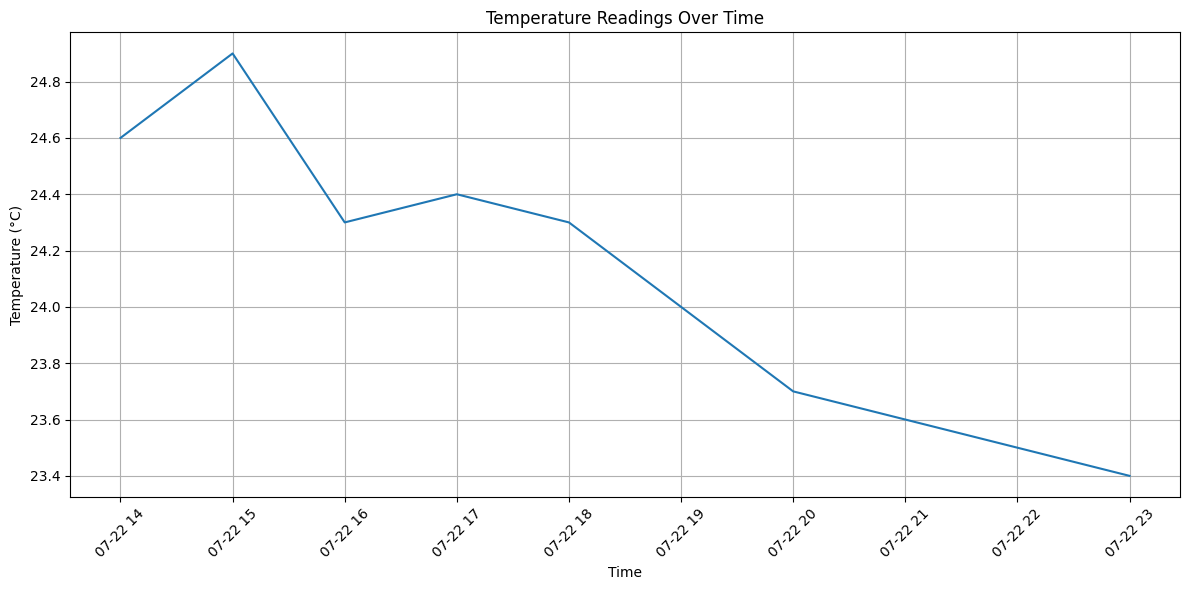

In [ ]:
# Plot the temperature readings
if not df.empty and 'Time' in df.columns and 'Temperature (°C)' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Time', y='Temperature (°C)', data=df)
    plt.title('Temperature Readings Over Time')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: DataFrame is empty or required columns ('Time', 'Temperature (°C)') are missing.")


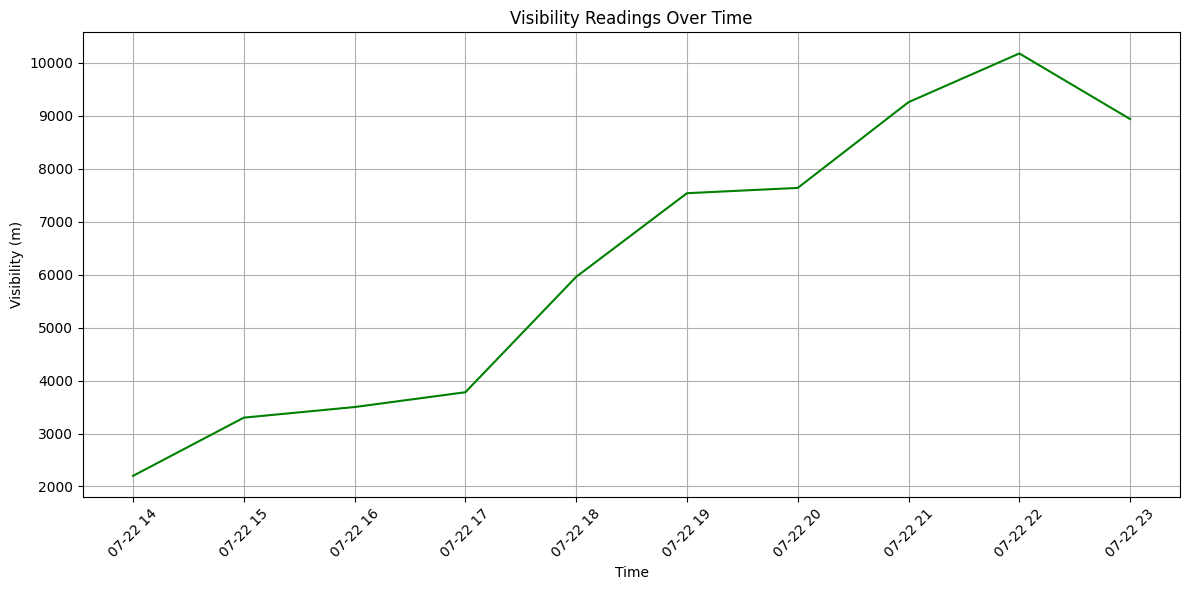

In [ ]:
# Plot the visibility readings
if not df.empty and 'Time' in df.columns and 'Visibility (m)' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Time', y='Visibility (m)', data=df, color='green')
    plt.title('Visibility Readings Over Time')
    plt.xlabel('Time')
    plt.ylabel('Visibility (m)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: DataFrame is empty or required columns ('Time', 'Visibility (m)') are missing.")